In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

In [40]:
def sigmoid_derivative_from_output(output):
    return output *(1-output)


In [41]:

X = np.array([1, 2, 4, 6, 7]).reshape(-1, 1)


Y = (X * 2).reshape(-1, 1)

n_samples = X.shape[0]


In [42]:

n_inputs = 1
n_hidden = 4
n_outputs = 1


W1 = np.random.randn(n_inputs, n_hidden) * 0.001
b1 = np.zeros((1, n_hidden))


W2 = np.random.randn(n_hidden, n_outputs) * 0.01
b2 = np.zeros((1, n_outputs))


In [43]:
def forward_propagation(X):
    z1 = np.dot(X, W1) + b1        
    a1 = sigmoid(z1)               

    z2 = np.dot(a1, W2) + b2       
    y_hat = z2            

    return z1, a1, z2, y_hat


In [44]:
def compute_loss(Y, Y_hat):
    return np.mean((Y - Y_hat) ** 2)


In [45]:
def back_propagation(X, Y, z1, a1, z2, Y_hat, lr):
    global W1, b1, W2, b2

   
    error_out = Y_hat - Y
    delta_out = error_out 

    dW2 = np.dot(a1.T, delta_out)
    db2 = np.sum(delta_out, axis=0, keepdims=True)

   
    error_hidden = np.dot(delta_out, W2.T)
    delta_hidden = error_hidden * sigmoid_derivative_from_output(a1)

    dW1 = np.dot(X.T, delta_hidden)
    db1 = np.sum(delta_hidden, axis=0, keepdims=True)

   
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1


In [46]:
epochs = 2000
learning_rate = 0.01
loss_list = []

for epoch in range(epochs):
    z1, a1, z2, Y_hat = forward_propagation(X)
    loss = compute_loss(Y, Y_hat)
    loss_list.append(loss)

    back_propagation(X, Y, z1, a1, z2, Y_hat, learning_rate)

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 84.7822
Epoch 200, Loss: 0.1391
Epoch 400, Loss: 0.0875
Epoch 600, Loss: 0.0823
Epoch 800, Loss: 0.0752
Epoch 1000, Loss: 0.0653
Epoch 1200, Loss: 0.1546
Epoch 1400, Loss: 0.1431
Epoch 1600, Loss: 0.1414
Epoch 1800, Loss: 0.1395


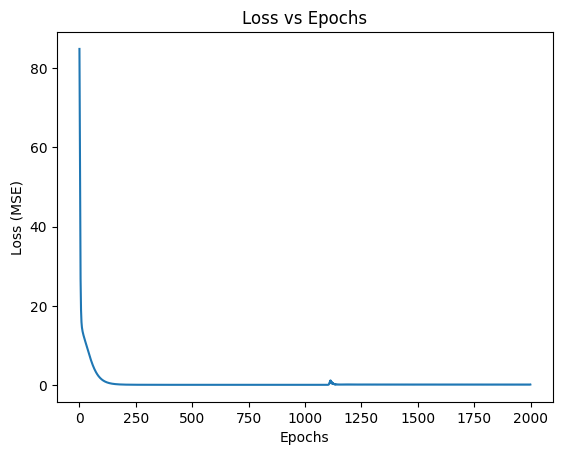

In [47]:
plt.plot(loss_list)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()


In [48]:
test_input = np.array([[5]])
_, _, _, prediction = forward_propagation(test_input)

print("Test Input:", test_input.flatten())
print("Predicted Output:", prediction.flatten())
print("Expected Output:", test_input.flatten() * 2)


Test Input: [5]
Predicted Output: [9.92447011]
Expected Output: [10]
